In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# IMPORTING DATA

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

Race & Driver Context
id: A unique identifier for each row/observation in the dataset.

Driver: An anonymized code representing the Formula 1 driver (e.g., D109, D086, ZON).

Race: The name of the Grand Prix where the data was recorded (e.g., Canadian Grand Prix, Dutch Grand Prix).

Year: The calendar year of the race season (e.g., 2022, 2025).

Tire & Stint Details
Compound: The type of tire compound being used during that lap. This is crucial for performance and degradation. The values include:

Slicks (Dry weather): SOFT, MEDIUM, HARD

Wet weather: INTERMEDIATE, WET

Stint: The current stint number for the driver in that race. A new stint starts every time a driver goes to the pits and changes tires (e.g., 1 for the starting tires, 2 after the first pit stop).

TyreLife: The age of the current set of tires in terms of laps driven on them. Higher values generally mean less grip and worse performance.

Cumulative_Degradation: A calculated metric showing the total wear, tear, or performance loss accumulated on the tires up to that lap.

Race Progression & Tracking
LapNumber: The specific lap of the race currently being completed (e.g., lap 50).

RaceProgress: The percentage of the total race distance completed, expressed as a decimal between 0 and 1 (e.g., 0.714 means the race is roughly 71% complete).

PitStop: Likely a binary flag or counter indicating if a pit stop occurred previously or if the driver is currently in the pit lane during that sequence.

Timing & Performance
LapTime (s): The total time it took the driver to complete the current lap, measured in seconds.

LapTime_Delta: The difference in lap time compared to a baseline (such as the previous lap, the driver's personal best, or the average grid pace). A negative number means the lap was faster than the baseline.

Track Position
Position: The driver's current position on the track field during that lap (e.g., 1 for the leader, 8 for eighth place).

Position_Change: The number of places the driver gained or lost compared to a prior point in the race (positive numbers mean places gained, negative numbers mean dropped positions).

Target Variable
PitNextLap: This is your target label (what you are trying to predict). It is a binary indicator:

1.0 = The driver will pull into the pit lane at the end of the next lap.

0.0 = The driver will stay out on track for the next lap.

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

# **EXPLORATORY DATA ANALYSIS**

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'PitStop'}>,
        <Axes: title={'center': 'LapNumber'}>],
       [<Axes: title={'center': 'Stint'}>,
        <Axes: title={'center': 'TyreLife'}>,
        <Axes: title={'center': 'Position'}>,
        <Axes: title={'center': 'LapTime (s)'}>],
       [<Axes: title={'center': 'LapTime_Delta'}>,
        <Axes: title={'center': 'Cumulative_Degradation'}>,
        <Axes: title={'center': 'RaceProgress'}>,
        <Axes: title={'center': 'Position_Change'}>],
       [<Axes: title={'center': 'PitNextLap'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

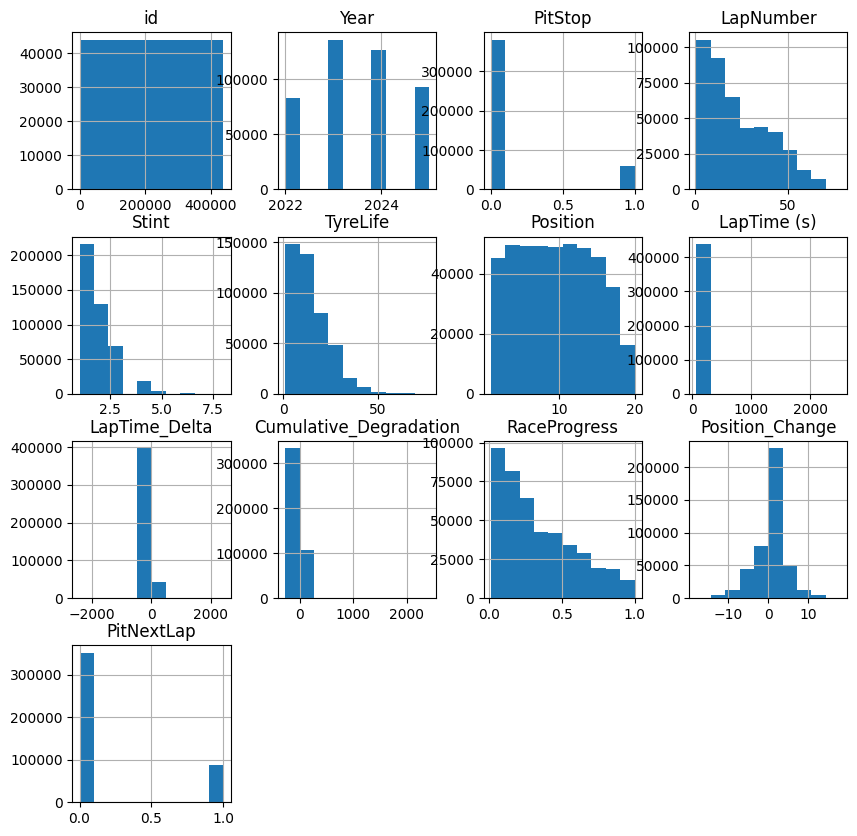

In [4]:
numeric_columns = train.select_dtypes(include = ['int64','float64'])
numeric_columns.hist(figsize = (10,10))

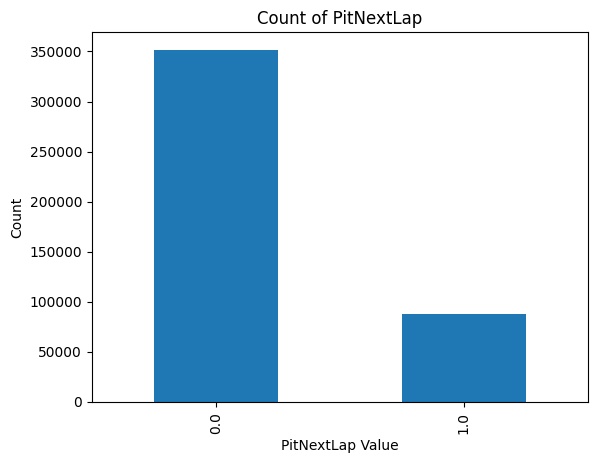

In [5]:


train['PitNextLap'].value_counts().plot(kind='bar')
plt.title('Count of PitNextLap')
plt.xlabel('PitNextLap Value')
plt.ylabel('Count')
plt.show()

In [6]:
train['Compound'].value_counts()

Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

<Axes: ylabel='LapTime_Delta'>

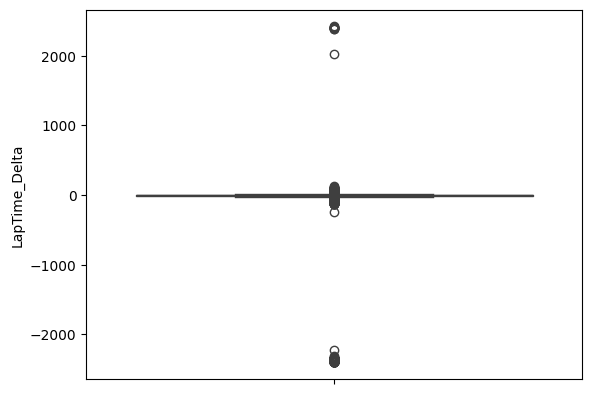

In [7]:
sns.boxplot(train['LapTime_Delta'])

<Axes: ylabel='Cumulative_Degradation'>

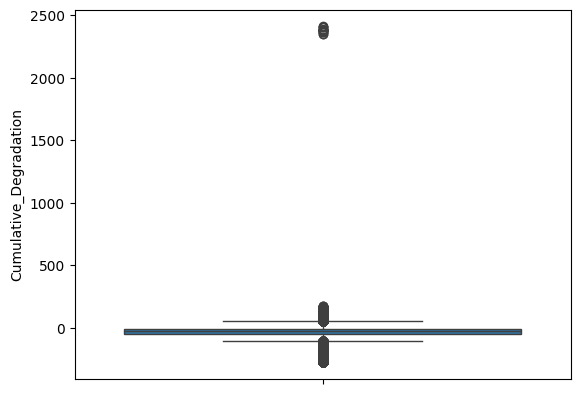

In [8]:
sns.boxplot(train['Cumulative_Degradation'])

/tmp/ipykernel_57/3586739355.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


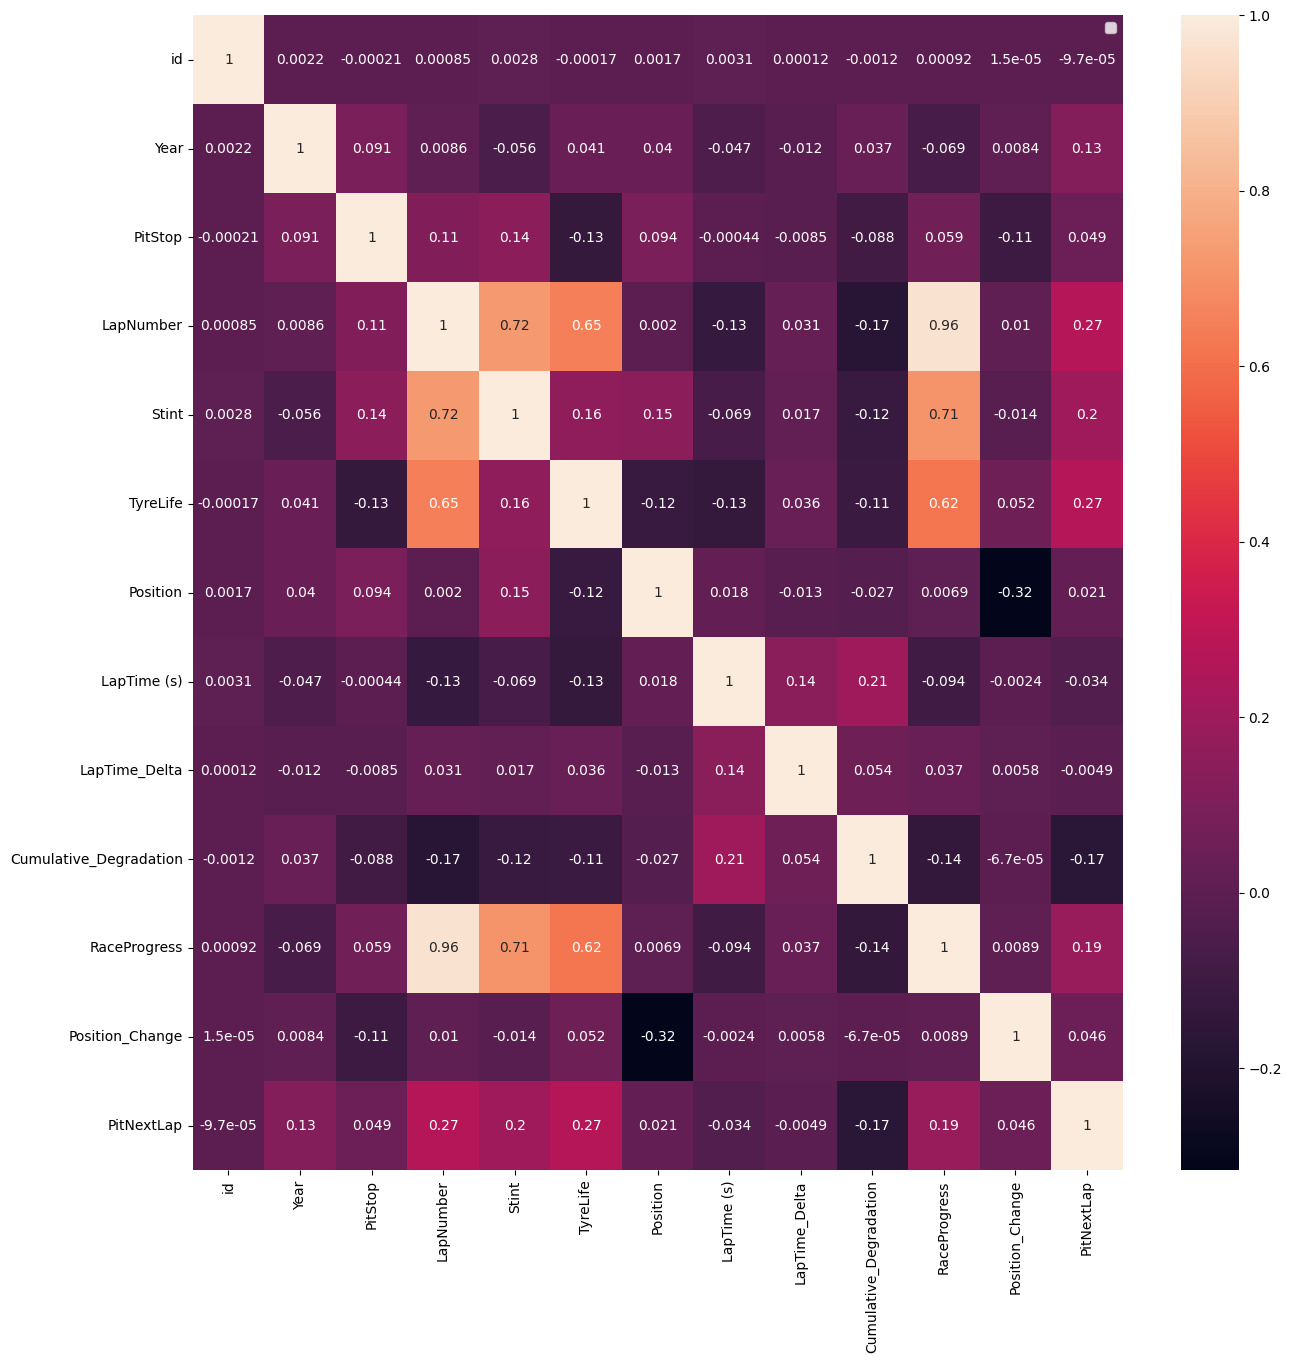

In [9]:
plt.figure(figsize=(15,15))
sns.heatmap(train.corr(numeric_only = True),annot = True)
plt.legend()
plt.show()

# **PREPROCESSING THE DATA & FEATURE ENGINEERING**

In [10]:
compound_75th = train.groupby('Compound')['TyreLife'].quantile(0.75).to_dict()
print("Thresholds:", compound_75th)

Thresholds: {'HARD': 25.0, 'INTERMEDIATE': 19.0, 'MEDIUM': 17.0, 'SOFT': 15.0, 'WET': 13.0}


In [11]:
train['TyreLife_75th_Threshold'] = train['Compound'].map(compound_75th)
train['TyreLife_Delta_From_75th'] = train['TyreLife'] - train['TyreLife_75th_Threshold']
train['Is_Tyre_Past_75th'] = (train['TyreLife'] > train['TyreLife_75th_Threshold']).astype(int)


test['TyreLife_75th_Threshold'] = test['Compound'].map(compound_75th)
test['TyreLife_Delta_From_75th'] = test['TyreLife'] - test['TyreLife_75th_Threshold']
test['Is_Tyre_Past_75th'] = (test['TyreLife'] > test['TyreLife_75th_Threshold']).astype(int)

new_train = train.copy()
new_test = test.copy()

# Features to add
# 1. Have the  tyres been changed
# 2. Progress of race start,end,mid
# 3. Is the speed decreasing
# 4. IS the driver loosing his position
# 5. No of laps remaining


# **ADDING NEW FEATURES**

In [12]:
#Have the tyres changed till now > 1 for yes, 0 for no 
new_train['Tyres_Changes'] = np.int64(new_train['Stint'] > 1)
new_test['Tyres_Changes'] = np.int64(new_test['Stint'] > 1)

In [15]:
#number of laps remaining to complete the race
new_train['Remaining_laps'] = new_train['Total_Laps']-new_train['LapNumber']
new_test['Remaining_laps'] = new_test['Total_Laps']-new_test['LapNumber']

In [16]:
 #Total number of laps in the race
new_train['Total_Laps'] = round((new_train['LapNumber']*100)/(new_train['RaceProgress']*100),0)
new_test['Total_Laps'] = round((new_test['LapNumber']*100)/(new_test['RaceProgress']*100),0)

In [17]:
# is the driver losing his position
new_train['Driver_losing_position'] = np.int64(new_train['Position_Change']>0)
new_test['Driver_losing_position'] = np.int64(new_test['Position_Change']>0)

In [18]:
new_train['Degradation_Effect'] = new_train['LapTime_Delta'] * new_train['Cumulative_Degradation']
new_test['Degradation_Effect'] = new_test['LapTime_Delta'] * new_test['Cumulative_Degradation']

In [19]:
new_train['Is_Pitstop_necessary'] = np.int64((new_train['PitStop'] == 0) & (new_train['TyreLife']>new_train['TyreLife_75th_Threshold']) &(new_train['Cumulative_Degradation'] <= -10.00) & (new_train['Driver_losing_position'] == 1))
new_test['Is_Pitstop_necessary'] = np.int64((new_test['PitStop'] == 0) & (new_test['TyreLife']>new_test['TyreLife_75th_Threshold']) &(new_test['Cumulative_Degradation'] <= -10.00) & (new_test['Driver_losing_position'] == 1))

In [20]:
bins = [-float('inf'), 0.33, 0.66, float('inf')]
labels = [1, 2, 3]
new_train['Race_Progress_cat'] = pd.cut(new_train['RaceProgress'], bins=bins, labels=labels).astype(int)
new_test['Race_Progress_cat'] = pd.cut(new_test['RaceProgress'], bins=bins, labels=labels).astype(int)

In [21]:
new_train['Degradation_Velocity'] = new_train['Cumulative_Degradation']/new_train['LapNumber']
new_test['Degradation_Velocity'] = new_test['Cumulative_Degradation']/new_test['LapNumber']

In [22]:
new_train['stint_normalized_tytelife'] = new_train['TyreLife']/new_train['TyreLife_75th_Threshold']
new_test['stint_normalized_tytelife'] = new_test['TyreLife']/new_test['TyreLife_75th_Threshold']

In [23]:
new_train['effect_of_progress'] = new_train['RaceProgress']*new_train['TyreLife']
new_test['effect_of_progress'] = new_test['RaceProgress']*new_test['TyreLife']

In [24]:
new_train['effect_of_position_degradation'] = new_train['Position']*new_train['Cumulative_Degradation']
new_test['effect_of_position_degradation'] = new_test['Position']*new_test['Cumulative_Degradation']

In [25]:
new_train['stint_life_remaining'] = new_train['TyreLife']*new_train['Remaining_laps']
new_test['stint_life_remaining'] = new_test['TyreLife']*new_test['Remaining_laps']

In [26]:
new_train2 = new_train.copy() # used further for catboost
new_test2 = new_test.copy()

In [27]:
train_catb = new_train.copy()
test_catb = new_test.copy()

In [28]:
new_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              439140 non-null  int64  
 1   Driver                          439140 non-null  object 
 2   Compound                        439140 non-null  object 
 3   Race                            439140 non-null  object 
 4   Year                            439140 non-null  int64  
 5   PitStop                         439140 non-null  int64  
 6   LapNumber                       439140 non-null  int64  
 7   Stint                           439140 non-null  int64  
 8   TyreLife                        439140 non-null  float64
 9   Position                        439140 non-null  int64  
 10  LapTime (s)                     439140 non-null  float64
 11  LapTime_Delta                   439140 non-null  float64
 12  Cumulative_Degra

In [29]:
train.shape

(439140, 19)

# ENCODING CATEGORICAL FEATURES AND CHECKING CORRELATION

In [30]:
from sklearn.preprocessing import OneHotEncoder
cat_columns = ['Compound','Race']
def encoding(df):
    encoded_df = pd.get_dummies(df,columns = cat_columns)
    return encoded_df
def dropping(encoded_df):
    encoded = encoding(encoded_df)
    new_df = encoded.drop(columns = ['id','Driver','Year'])
    return new_df
new_train = dropping(new_train)
new_test = dropping(new_test)


In [31]:
new_train.head()

,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,...,False,False,False,False,False,False,False,False,False,False
1,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,...,False,False,False,False,False,False,False,False,False,False
2,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,...,False,False,False,False,False,False,False,False,False,False
3,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,...,False,False,False,True,False,False,False,False,False,False
4,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,...,False,False,False,False,False,False,False,False,False,False


<Axes: >

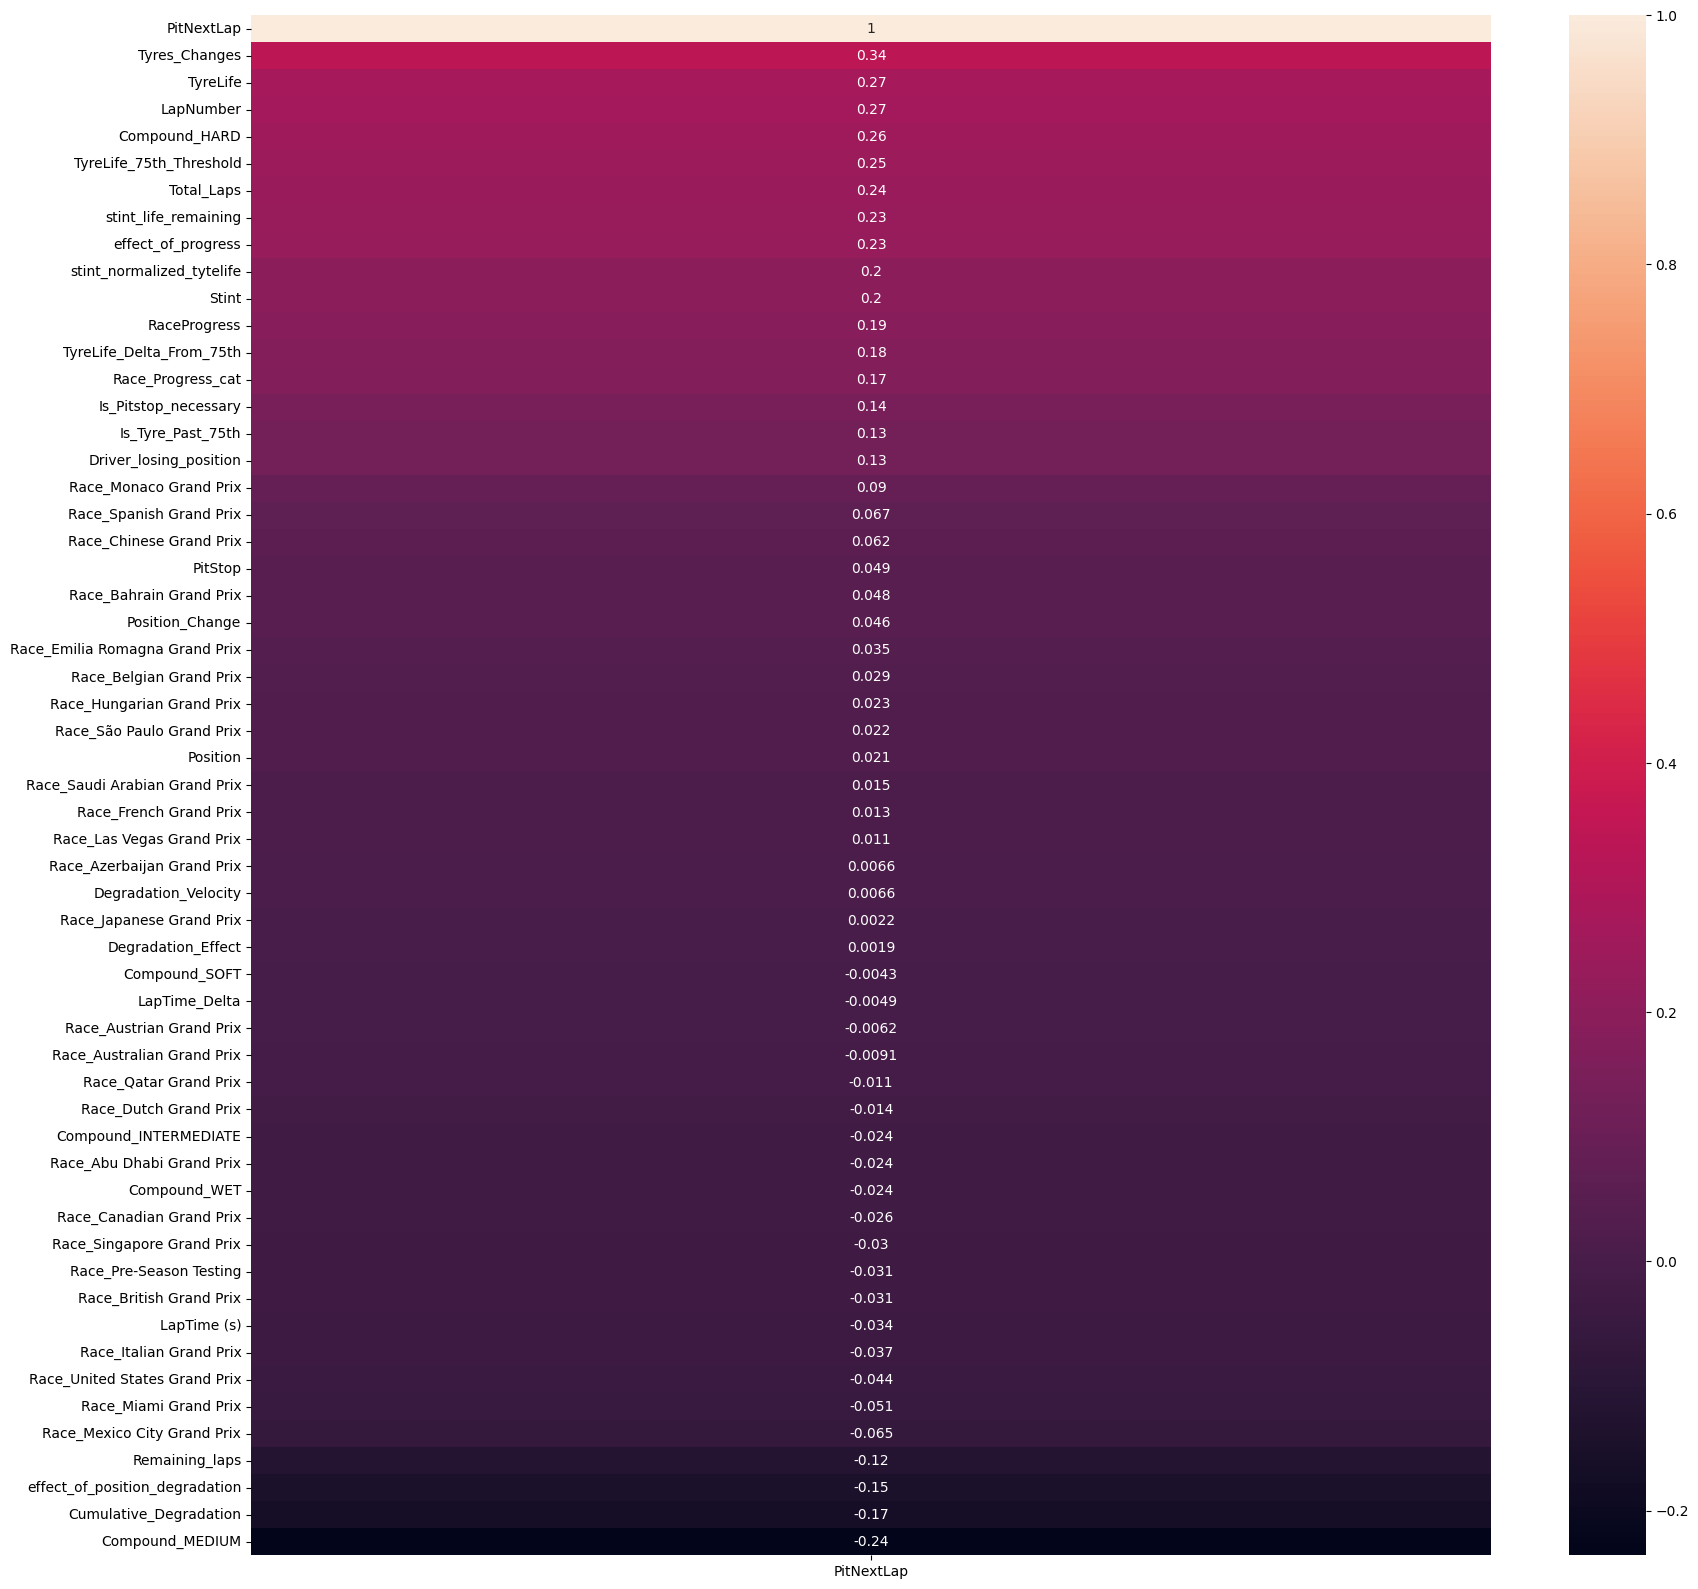

In [32]:
plt.figure(figsize = (20,20))
sns.heatmap((new_train.corr(numeric_only = True)['PitNextLap'].sort_values(ascending = False)).to_frame(),annot = True)


# **SPLITTING THE DATA TO PROVIDE MODEL**

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X = new_train.drop(columns = 'PitNextLap')
y = train['PitNextLap']
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify = y,test_size = 0.3)

In [35]:
new_test = new_test[X_train.columns]

In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
transformed_train = sc.fit_transform(X_train)
transformed_val = sc.transform(X_val)
transformed_test = sc.transform(new_test)

In [37]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
ratio = negative_count / positive_count

print(f"Negative class count: {negative_count}")
print(f"Positive class count: {positive_count}")
print(f"Calculated scale_pos_weight: {ratio:.4f}")

Negative class count: 246231
Positive class count: 61167
Calculated scale_pos_weight: 4.0256


In [38]:
X = train_catb.drop(columns = ['id','Driver','Year','PitNextLap'])
y = train_catb['PitNextLap']
X_train_catb,X_val_catb,y_train_catb,y_val_catb = train_test_split(X,y,stratify = y,test_size = 0.3)

# **TRYING RANDOMFOREST TO PREDICT PITSTOP**

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
forst = RandomForestClassifier(n_estimators = 300,
                               random_state = 42,
                               max_depth = 13,
                               min_samples_split = 10,
                               min_samples_leaf = 4,
                               n_jobs = -1,
                               class_weight = 'balanced'
                              )
model = forst.fit(X_train,y_train)

In [41]:
y_pred = model.predict(X_val)
y_pred_prob = model.predict_proba(X_val)[:,1]

In [42]:
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score

In [43]:
print(classification_report(y_pred,y_val))

              precision    recall  f1-score   support

         0.0       0.85      0.97      0.91     93131
         1.0       0.88      0.60      0.71     38611

    accuracy                           0.86    131742
   macro avg       0.87      0.78      0.81    131742
weighted avg       0.86      0.86      0.85    131742



In [44]:
print(accuracy_score(y_pred,y_val))

0.8576232332893079


In [45]:
print(roc_auc_score(y_val,y_pred_prob))

0.9333319735079157


In [46]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_val, y_pred_prob)
print(f"PR AUC Score: {pr_auc:.5f}")

PR AUC Score: 0.75998


# **Trying XGBOOST FOR PREDICTING PITSTOP**

In [47]:

from xgboost import XGBClassifier

In [48]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
ratio = negative_count / positive_count

print(f"Negative class count: {negative_count}")
print(f"Positive class count: {positive_count}")
print(f"Calculated scale_pos_weight: {ratio:.4f}")

Negative class count: 246231
Positive class count: 61167
Calculated scale_pos_weight: 4.0256


In [49]:
xgb_model = XGBClassifier(
    n_estimators=9000,       
    max_depth=7,                
    learning_rate=0.02,         
    subsample=0.8,              
    scale_pos_weight = ratio,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

In [50]:
model = xgb_model.fit(transformed_train,y_train,eval_set = [(transformed_val,y_val)],verbose = 100)

[0]	validation_0-logloss:0.68244
[100]	validation_0-logloss:0.36948
[200]	validation_0-logloss:0.33560
[300]	validation_0-logloss:0.32321
[400]	validation_0-logloss:0.31559
[500]	validation_0-logloss:0.31032
[600]	validation_0-logloss:0.30621
[700]	validation_0-logloss:0.30275
[800]	validation_0-logloss:0.29998
[900]	validation_0-logloss:0.29766
[1000]	validation_0-logloss:0.29561
[1100]	validation_0-logloss:0.29363
[1200]	validation_0-logloss:0.29200
[1300]	validation_0-logloss:0.29049
[1400]	validation_0-logloss:0.28915
[1500]	validation_0-logloss:0.28787
[1600]	validation_0-logloss:0.28661
[1700]	validation_0-logloss:0.28556
[1800]	validation_0-logloss:0.28443
[1900]	validation_0-logloss:0.28346
[2000]	validation_0-logloss:0.28257
[2100]	validation_0-logloss:0.28169
[2200]	validation_0-logloss:0.28086
[2300]	validation_0-logloss:0.28010
[2400]	validation_0-logloss:0.27932
[2500]	validation_0-logloss:0.27853
[2600]	validation_0-logloss:0.27786
[2700]	validation_0-logloss:0.27721
[280

In [51]:
y_preds_prob = model.predict_proba(transformed_val)[:,1]
y_preds = model.predict(transformed_val)
print(roc_auc_score(y_val,y_preds_prob))
print(average_precision_score(y_val,y_preds_prob))
print(classification_report(y_val,y_preds))


0.9464573576765805
0.8093255145200631
              precision    recall  f1-score   support

         0.0       0.96      0.89      0.93    105528
         1.0       0.67      0.86      0.75     26214

    accuracy                           0.89    131742
   macro avg       0.81      0.87      0.84    131742
weighted avg       0.90      0.89      0.89    131742



In [52]:
test_probabilities = xgb_model.predict_proba(transformed_test)[:, 1]
submission_df = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': test_probabilities
})
submission_df.to_csv('submission.csv', index=False)
print("Success! 'submission.csv' has been generated and saved.")
print(submission_df.head())

Success! 'submission.csv' has been generated and saved.
       id  PitNextLap
0  439140    0.019105
1  439141    0.001424
2  439142    0.001550
3  439143    0.115059
4  439144    0.967829


In [53]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=9000,
              n_jobs=-1, num_parallel_tree=None, ...)

# **TRYING LIGHTGBM FOOR PREDICTING PITSTOP**

In [54]:
import lightgbm as lgb

# Initialize the LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=1460,     
    learning_rate=0.025407119510271456,     
    max_depth=8,            
    num_leaves=145,          
    scale_pos_weight=ratio,
    min_child_samples=34,  
    subsample=0.507641537701047, 
    colsample_bytree=0.9850958296317915,
    reg_alpha = 3.9562550871223565,
    reg_lambda = 0.002585285086801147, 
    random_state=42,
    n_jobs=-1,
    verbose = -1
)

In [55]:
lgb_model = lgb_model.fit(transformed_train, y_train)

In [56]:
y_preds_prob = lgb_model.predict_proba(transformed_val)[:,1]
y_preds = lgb_model.predict(transformed_val)
print(roc_auc_score(y_val,y_preds_prob))
print(classification_report(y_val,y_preds))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9481356447576157
              precision    recall  f1-score   support

         0.0       0.97      0.87      0.92    105528
         1.0       0.63      0.90      0.74     26214

    accuracy                           0.87    131742
   macro avg       0.80      0.88      0.83    131742
weighted avg       0.90      0.87      0.88    131742



# **TRYING CATBOOST TO PREDICT PITSTOP**

In [57]:
new_train2.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,Remaining_laps,Driver_losing_position,Degradation_Effect,Is_Pitstop_necessary,Race_Progress_cat,Degradation_Velocity,stint_normalized_tytelife,effect_of_progress,effect_of_position_degradation,stint_life_remaining
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,...,20.0,1,-158.987716,0,3,0.420380,1.560000,27.857143,168.152,780.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,...,51.0,0,7280.342719,0,2,-8.266926,0.280000,2.423077,-892.828,357.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,...,13.0,1,757.988660,0,3,-1.703881,0.880000,18.027778,-1306.877,286.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,...,24.0,0,53.640976,0,1,-3.662000,0.117647,0.153846,-51.268,48.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,...,46.0,1,-126.756135,0,2,-0.543808,0.240000,2.166667,-28.278,276.0


In [58]:
X_catb = new_train2.drop(columns = ['PitNextLap','id','Driver','Year'])
y_catb = new_train2['PitNextLap']
X_train_catb,X_val_catb,y_train_catb,y_val_catb = train_test_split(X_catb,y_catb,stratify = y,test_size = 0.2,random_state = 42)

In [59]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

cat_model = CatBoostClassifier(
    iterations=2131,       
    learning_rate=0.040125662537790874,          
    depth=10,
    l2_leaf_reg=9.886225622609953,        
    bagging_temperature = 0.6752142978360671,
    random_strength = 0.36313871063983677,
    border_count = 196,
    scale_pos_weight=4.0256,
    eval_metric='AUC',
    random_seed=42,      
    task_type="CPU",
    verbose = 100 
)

print("Training CatBoost Classifier...")
cat_model.fit(
    transformed_train, y_train, 
    eval_set=(transformed_val, y_val), 
    early_stopping_rounds=50
)

cat_probs = cat_model.predict_proba(transformed_val)[:, 1]
cat_preds = cat_model.predict(transformed_val)
print(f"CatBoost ROC AUC: {roc_auc_score(y_val, cat_probs):.5f}")
print(f"CatBoost PR AUC: {average_precision_score(y_val, cat_probs):.5f}")
print(classification_report(y_val, cat_preds))

Training CatBoost Classifier...
0:	test: 0.9011459	best: 0.9011459 (0)	total: 210ms	remaining: 7m 28s
100:	test: 0.9328285	best: 0.9328285 (100)	total: 15.1s	remaining: 5m 3s
200:	test: 0.9394713	best: 0.9394713 (200)	total: 30s	remaining: 4m 47s
300:	test: 0.9426324	best: 0.9426324 (300)	total: 45s	remaining: 4m 33s
400:	test: 0.9444609	best: 0.9444609 (400)	total: 1m	remaining: 4m 19s
500:	test: 0.9454725	best: 0.9454725 (500)	total: 1m 15s	remaining: 4m 5s
600:	test: 0.9461369	best: 0.9461369 (600)	total: 1m 30s	remaining: 3m 51s
700:	test: 0.9466984	best: 0.9466984 (700)	total: 1m 46s	remaining: 3m 36s
800:	test: 0.9470714	best: 0.9470714 (800)	total: 2m 1s	remaining: 3m 21s
900:	test: 0.9473294	best: 0.9473294 (900)	total: 2m 17s	remaining: 3m 7s
1000:	test: 0.9475379	best: 0.9475379 (1000)	total: 2m 32s	remaining: 2m 52s
1100:	test: 0.9476770	best: 0.9476770 (1100)	total: 2m 47s	remaining: 2m 36s
1200:	test: 0.9477573	best: 0.9477573 (1200)	total: 3m 2s	remaining: 2m 21s
1300:	te

# **TRYING SOFT VOTING ENSEMBLE**

In [60]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report


xgb_val_probs = model.predict_proba(transformed_val)[:, 1]
lgb_val_probs = lgb_model.predict_proba(transformed_val)[:, 1]
ensemble_val_probs = (0.5 * xgb_val_probs) + (0.5 * lgb_val_probs)
ensemble_val_preds = (ensemble_val_probs > 0.5).astype(int)
print(" XGB + LGB ENSEMBLE VALIDATION METRICS ")
print(f"Ensemble ROC AUC: {roc_auc_score(y_val, ensemble_val_probs):.5f}")
print(f"Ensemble PR AUC:  {average_precision_score(y_val, ensemble_val_probs):.5f}")
print("\nClassification Report:")
print(classification_report(y_val, ensemble_val_preds))
print("Generating final submission file using the XGB+LGB ensemble...")
xgb_test_probs = xgb_model.predict_proba(transformed_test)[:, 1]
lgb_test_probs = lgb_model.predict_proba(transformed_test)[:, 1]

ensemble_test_probs = (0.5 * xgb_test_probs) + (0.5 * lgb_test_probs)

submission_ensemble = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': ensemble_test_probs
})

submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print("'submission_ensemble.csv' has been generated.")
print(submission_ensemble.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 XGB + LGB ENSEMBLE VALIDATION METRICS 
Ensemble ROC AUC: 0.94838
Ensemble PR AUC:  0.81457

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.92    105528
         1.0       0.65      0.88      0.75     26214

    accuracy                           0.88    131742
   macro avg       0.81      0.88      0.84    131742
weighted avg       0.90      0.88      0.89    131742

Generating final submission file using the XGB+LGB ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


'submission_ensemble.csv' has been generated.
       id  PitNextLap
0  439140    0.021810
1  439141    0.002338
2  439142    0.003090
3  439143    0.206038
4  439144    0.949088


In [61]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=9000,
              n_jobs=-1, num_parallel_tree=None, ...)


In [62]:
lgb_model

LGBMClassifier(colsample_bytree=0.9850958296317915,
               learning_rate=0.025407119510271456, max_depth=8,
               min_child_samples=34, n_estimators=1460, n_jobs=-1,
               num_leaves=145, random_state=42, reg_alpha=3.9562550871223565,
               reg_lambda=0.002585285086801147,
               scale_pos_weight=np.float64(4.025552994261612),
               subsample=0.507641537701047, verbose=-1)

In [63]:
cat_model

CatBoostClassifier(bagging_temperature=0.6752142978360671, border_count=196, depth=10, eval_metric='AUC', iterations=2131, l2_leaf_reg=9.886225622609953, learning_rate=0.040125662537790874, random_seed=42, random_strength=0.36313871063983677, scale_pos_weight=4.0256, task_type='CPU', verbose=100)

In [65]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

xgb_val_probs = model.predict_proba(transformed_val)[:, 1]
lgb_val_probs = lgb_model.predict_proba(transformed_val)[:, 1]
cat_val_probs = cat_model.predict_proba(transformed_val)[:, 1]


ensemble_val_probs = (0.4 * xgb_val_probs) + (0.3 * lgb_val_probs) + (0.3 * cat_val_probs)
ensemble_val_preds = (ensemble_val_probs > 0.5).astype(int)


print(" 3-MODEL ENSEMBLE VALIDATION METRICS ")
print(f"Ensemble ROC AUC: {roc_auc_score(y_val, ensemble_val_probs):.5f}")
print(f"Ensemble PR AUC:  {average_precision_score(y_val, ensemble_val_probs):.5f}")
print("\nClassification Report:")
print(classification_report(y_val, ensemble_val_preds))
print("Generating final submission file using the 3-model ensemble...")
xgb_test_probs = model.predict_proba(transformed_test)[:, 1]
lgb_test_probs = lgb_model.predict_proba(transformed_test)[:, 1]
cat_test_probs = cat_model.predict_proba(transformed_test)[:, 1]

ensemble_test_probs = (0.4 * xgb_test_probs) + (0.3 * lgb_test_probs) + (0.3 * cat_test_probs)

submission_ensemble = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': ensemble_test_probs
})

submission_ensemble.to_csv('submission_ensemble_3model.csv', index=False)
print("🎉 Success! 'submission_ensemble_3model.csv' has been generated.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 3-MODEL ENSEMBLE VALIDATION METRICS 
Ensemble ROC AUC: 0.94885
Ensemble PR AUC:  0.81587

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.92    105528
         1.0       0.65      0.88      0.75     26214

    accuracy                           0.88    131742
   macro avg       0.81      0.88      0.83    131742
weighted avg       0.90      0.88      0.89    131742

Generating final submission file using the 3-model ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🎉 Success! 'submission_ensemble_3model.csv' has been generated.
